In [1]:
import scanpy as sc
import pandas as pd
import numpy as nu
from scipy.sparse import csr_matrix

from matplotlib import pyplot as plt
from matplotlib import rcParams
import sys
import time



In [2]:
import sys
sys.path.append('../src/resolute')
import resolute as rs

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white')

## neurons 2000 dataset (mouse brain)
Info and reference: https://www.10xgenomics.com/resources/datasets/2-k-brain-cells-from-an-e-18-mouse-2-standard-2-1-0

In [3]:
adata = sc.read_h5ad("../../tests/datasets/neurons_2000/processed_data.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 920 × 2084
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

--- Running CALINSKI Scoring ---
Performing 19 parallel clusterings, using 19/64 CPU cores


Optimizing CALINSKI: 100%|██████████| 19/19 [00:05<00:00,  3.65it/s]


Detected 4 local minima at resolutions: [0.4, 1.0, 1.2000000000000002, 1.7000000000000002]
Suggested Resolution (Deepest Dip): 1.00

--- Running Bootstrap Stability Analysis (optimized) ---
Performing 19 parallel bootstraps (50 iterations each), using 19/64 CPU cores


Evaluating Stability: 100%|██████████| 19/19 [00:21<00:00,  1.11s/it]


Detected 4 stable local maxima at resolutions: [0.4, 0.8, 1.0, 1.3000000000000003]
Suggested Stability Resolution (Highest Peak): 0.40


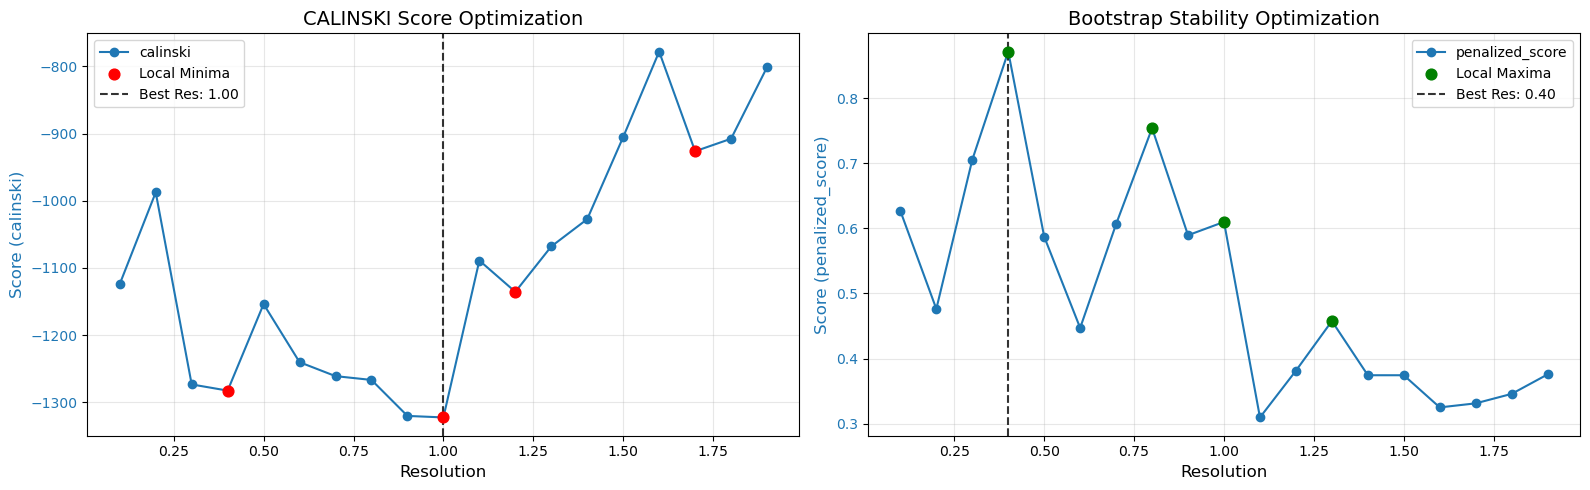


Optimization Summary for CALINSKI & Stability
-----------------------------------------------------------------------------------------------------
Resolution | CALINSKI Score   | Clusters (clustering_score) | Stability Score  | Clusters (Stability)
-----------------------------------------------------------------------------------------------------
0.1        | -1123.9273       | 4                           | 0.6269           | 4                   
0.2        | -987.5088        | 5                           | 0.4763           | 5                   
0.3        | -1273.4225       | 5                           | 0.7055           | 5                   
0.4        | -1282.6187       | 5                           | 0.8718           | 5                   
0.5        | -1153.8007       | 6                           | 0.5873           | 6                   
0.6        | -1240.3178       | 7                           | 0.4471           | 7                   
0.7        | -1261.0758       | 7  

In [5]:
# making it light-weight

results = rs.run_resolute(
    adata, 
    score_value='calinski', 
    use_rep='X_umap', 
    stability_use_rep = 'X_pca',
    compute_stability=True, 
    n_iterations=50
)


--- Running CALINSKI Scoring ---
Performing 19 parallel clusterings, using 19/64 CPU cores


Optimizing CALINSKI: 100%|██████████| 19/19 [00:05<00:00,  3.39it/s]


Detected 4 local minima at resolutions: [0.4, 1.0, 1.2000000000000002, 1.7000000000000002]
Suggested Resolution (Deepest Dip): 1.00

--- Running Bootstrap Stability Analysis ---
Performing 19 parallel bootstraps (50 iterations each), using 19/64 CPU cores


Evaluating Stability: 100%|██████████| 19/19 [00:25<00:00,  1.34s/it]


Detected 4 stable local maxima at resolutions: [0.4, 0.8, 1.0, 1.3000000000000003]
Suggested Stability Resolution (Highest Peak): 0.40


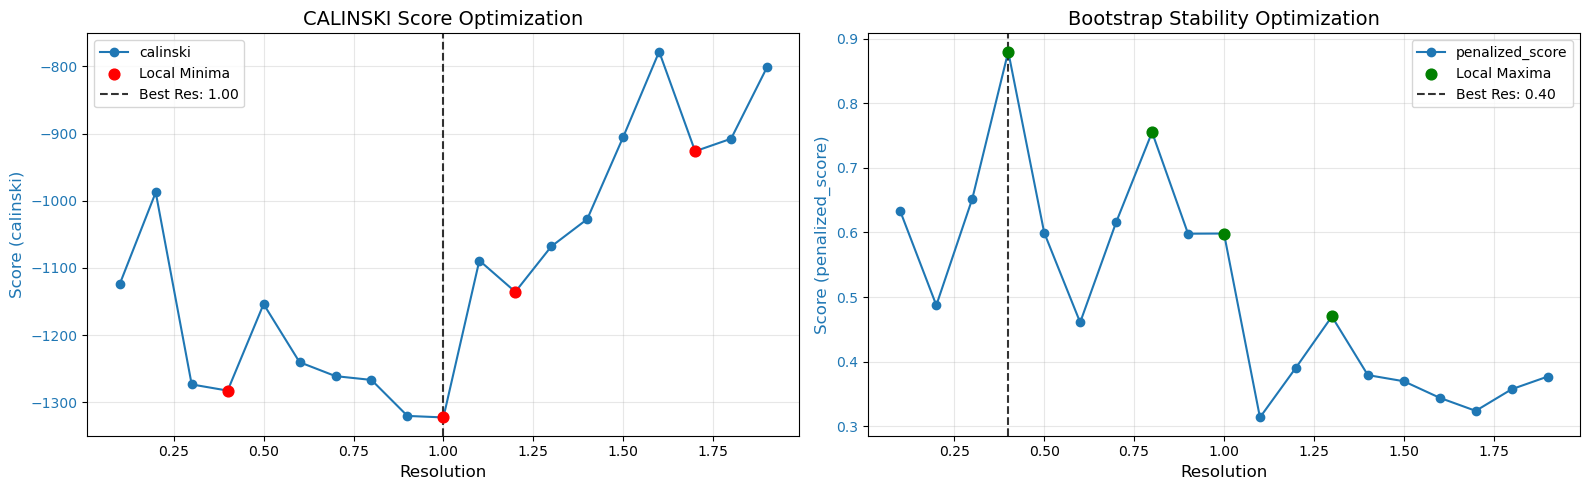

Optimization Summary for CALINSKI & Stability
-----------------------------------------------------------------------------------------------------
Resolution | CALINSKI Score   | Clusters (clustering_score) | Stability Score  | Clusters (Stability)
-----------------------------------------------------------------------------------------------------
0.1        | -1123.9273       | 4                           | 0.6326           | 4                   
0.2        | -987.5088        | 5                           | 0.4872           | 5                   
0.3        | -1273.4225       | 5                           | 0.6523           | 5                   
0.4        | -1282.6187       | 5                           | 0.8803           | 5                   
0.5        | -1153.8007       | 6                           | 0.5997           | 6                   
0.6        | -1240.3178       | 7                           | 0.4607           | 7                   
0.7        | -1261.0758       | 7   

In [4]:
# changed to flavor=igraph, directed=false for future compatibility (following scanpy warnings)

results = bc.run_bachclue(
    adata, 
    score_value='calinski', 
    use_rep='X_umap', 
    stability_use_rep = 'X_pca',
    compute_stability=True, 
    n_iterations=50
)


Performing 14 parallel clusterings, using 14/64 CPU cores


/home/jovyan/ifbdata/spatial_cell_id/Marco/clustering_optimum/bachclue/tests/../src/bachclue/bachclue.py:18: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added=clustering_name, resolution=r)
/home/jovyan/ifbdata/spatial_cell_id/Marco/clustering_optimum/bachclue/tests/../src/bachclue/bachclue.py:18: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added=clustering_name, resolution=r)
/home/jovyan/ifbdata/spatial_cell_id/Marco/clustering_optimum/bachclue/tests/../src/bachclue/bachclue.py:18: FutureWarning: In the future, the default backend for

Detected 2 local minima at resolutions: [0.4, 1.1]
Suggested Resolution (Deepest Dip): 1.10


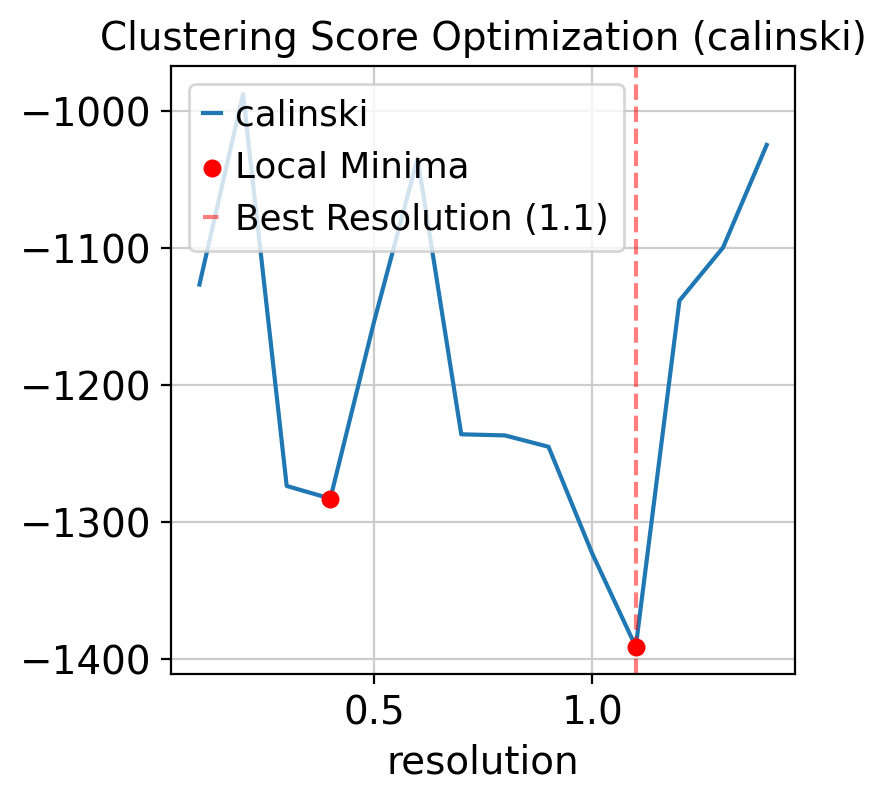

Execution time: 5.15 seconds


In [5]:
start_time = time.time()
a = bc.clustering_score(adata, score_value = 'calinski', min_res=0.1,max_res=1.5,step=0.1, plot=True, dim_reduction = 'X_umap')
end_time = time.time()

print(f"Execution time: {end_time - start_time:.2f} seconds")

Performing 14 parallel clusterings
Using 14/32 CPU cores
Starting parallel computation with Joblib using 14 cores...

Best resolution: 0.30


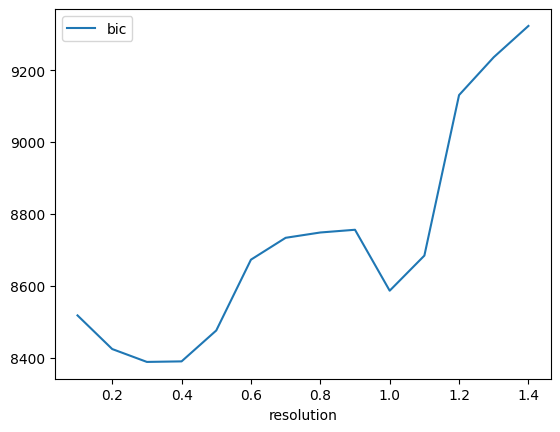

Execution time: 1.57 seconds


In [10]:
start_time = time.time()
a = bc.clustering_score(adata, score_value = 'bic', min_res=0.1,max_res=1.5,step=0.1, plot=True, dim_reduction = 'umap')
end_time = time.time()

print(f"Execution time: {end_time - start_time:.2f} seconds")

/opt/conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


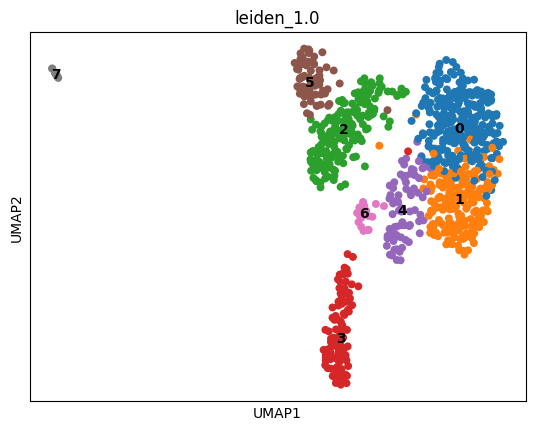

/opt/conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


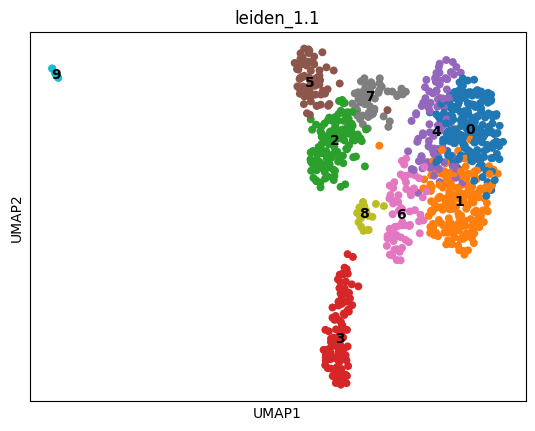

In [4]:
for res in [1.0,1.1]:
    sc.tl.leiden(adata, key_added="leiden_%s" %res, resolution=res)
    sc.pl.umap(adata, color="leiden_%s" %res,legend_loc="on data")

https://academic.oup.com/bioinformatics/article/35/17/3038/5289328

This dataset contains 2022 cells of a combined cortex, hippocampus and sub ventricular zone of an E18 mouse. Pre-analysis clustered the cells into 8 sub-groups of different types of neurons. 

The same number of clusters is found using our algorithm's best resolution (1.1)


----

From 10X Genomics' cloupe file there are 9 clusters
